# Deep Neural Network for MultiClass Classification

## Stage 1: We load the data and required libraries.

For this example, we use the dataset MNIST, which configures a problem of multiclass clasification (10 classes). The idea is to predict a number (0-9) form 28x28 images.

In [1]:
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
# MNIST dataset is available in pytorch

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [3]:
# Showing some examples
img, label = training_data[0]
print(img.shape, label)

torch.Size([1, 28, 28]) 5


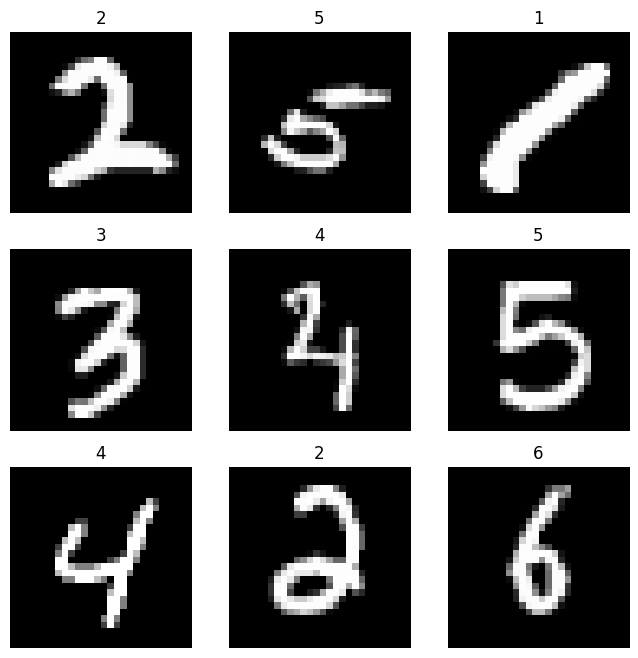

In [4]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [5]:
# We define an object to load the data
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

## Stage 2: Deep Neural Network definiton.

In [6]:
# We do this to use the GPU (if we only use CPU, the training will take a lot of time)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # images 28x28x1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0),  # Of = (Nf - f)/s + 1 = (28 - 3)/1 + 1
            # 26x26x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Of = (Nf - f)/s + 1 = (26 - 2)/2 + 1
            # 13x13x32 #(filas - tamañoFiltro)/stride + 1

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0),  # Of = (Nf - f)/s + 1 = (13 - 3)/1 + 1
            nn.ReLU(),
            # 11x11x64

            ## flatten()
            nn.Flatten(), #7744
            # Vector (ya es compatible con fully-connected)


            # Capas fully-connected
            nn.Linear(11*11*64, 32), # The previous layer has 13*13*64 units.
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(16, 10)
            # Note that the output layer has 10 units, Also
            # notice that we don't use any activation. This is because the loss
            # function computes the Softmax function internally.

    def forward(self, x):
        # This method is used to compute the output given a particular input x.
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits

In [8]:
# WE can verify the built network
model = NeuralNetwork()
model.to(device) # This is to define the model in the GPU
print(model)

NeuralNetwork(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=7744, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
  )
  (classifier): Linear(in_features=16, out_features=10, bias=True)
)


In [9]:
# We define the hyperparameters and the loss function
learning_rate = 0.001
epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
# The optimization loop.

loss_tr = []
loss_te = []
for epoch in range(epochs):
  for x, y in train_dataloader:
    # The variable should be sent to the GPU
    x = x.to(device)
    y = y.to(device)
    # Make predictions
    model.train()
    y_pred = model(x)
    # Compute the loss of current predictions
    loss = loss_fn(y_pred, y)
    # Clean the gradients
    optimizer.zero_grad()
    # Perform backpropagation
    loss.backward()
    # update weights
    optimizer.step()
    # Storing the training and test losses
    loss_tr.append(loss.item())
    loss_test = 0
  # since we're not training, we don't need to calculate the gradients for our outputs
  with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images)
        loss_test += loss_fn(outputs, labels).item() * labels.size(0)

  loss_te.append(loss_test/len(test_dataloader.dataset))
  print("epoch {} loss: {:.4f} test_loss: {:.4f}".format(epoch + 1,loss.item(),loss_test/len(test_dataloader.dataset)))

epoch 1 loss: 0.0174 test_loss: 0.0783
epoch 2 loss: 0.0020 test_loss: 0.0720
epoch 3 loss: 0.0523 test_loss: 0.0522
epoch 4 loss: 0.0137 test_loss: 0.0486
epoch 5 loss: 0.0435 test_loss: 0.0434
epoch 6 loss: 0.0009 test_loss: 0.0439
epoch 7 loss: 0.0013 test_loss: 0.0450
epoch 8 loss: 0.0038 test_loss: 0.0423
epoch 9 loss: 0.0242 test_loss: 0.0382
epoch 10 loss: 0.1258 test_loss: 0.0465


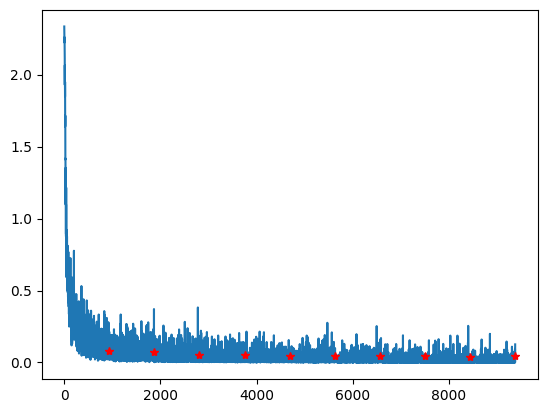

In [11]:
# Plot the losses for the train and test sets
import numpy as np
plt.plot(loss_tr)
plt.plot(np.arange(1,11)*len(train_dataloader.dataset)//64,loss_te, 'r*')
plt.show()

In [12]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 98 %


## Stage 4: Visualize Latent Space

In [13]:
import torch.nn as nn
import numpy as np
import torch # Ensure torch is imported

# To visualize the latent space, we need to extract the features from a layer before the final classification layer.
# In our model, the layer `nn.Linear(16, 10)` is the final output layer, so we'll take the output of the previous `nn.Linear(32, 16)` as our latent space.

# Create a new model that outputs the latent space representation
class LatentSpaceModel(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        # Take all layers up to the second to last linear layer, which is nn.Linear(32, 16), found at index 6 of original_model.encoder
        # The encoder has 8 layers (0-7). We want layers 0-6 (inclusive), so we slice up to index 7.
        self.latent_extractor = nn.Sequential(*list(original_model.encoder.children())[:7])

    def forward(self, x):
        return self.latent_extractor(x)

# Instantiate the latent space model
latent_model = LatentSpaceModel(model).to(device)
latent_model.eval() # Set to evaluation mode

# Extract latent features and corresponding labels for the test dataset
latent_features = []
actual_labels = []

with torch.no_grad():
    for data, labels in test_dataloader:
        data = data.to(device)
        outputs = latent_model(data)
        latent_features.append(outputs.cpu().numpy())
        actual_labels.append(labels.cpu().numpy())

latent_features_np = np.concatenate(latent_features, axis=0)
actual_labels_np = np.concatenate(actual_labels, axis=0)

print(f"Shape of extracted latent features: {latent_features_np.shape}")
print(f"Shape of actual labels: {actual_labels_np.shape}")

Shape of extracted latent features: (10000, 32)
Shape of actual labels: (10000,)


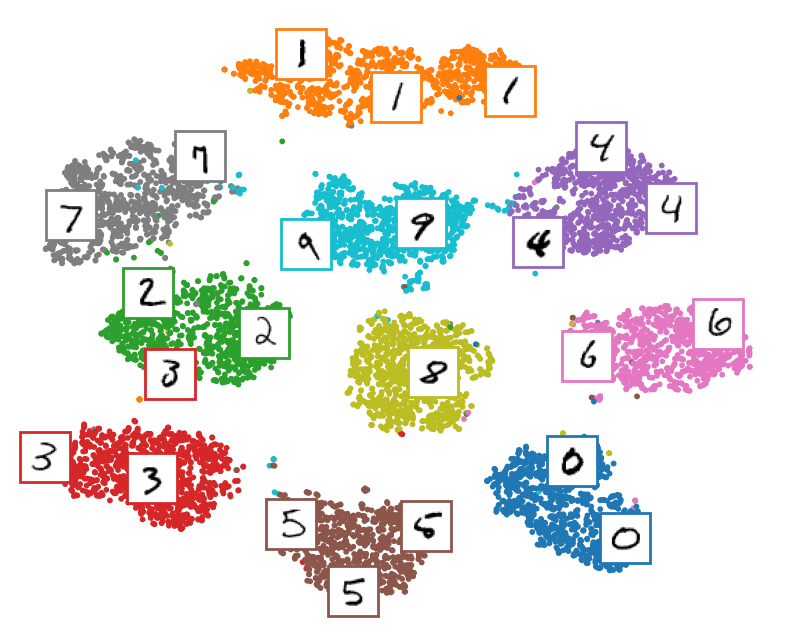

In [16]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.offsetbox

def plot_embeddings_tsne(X_data, y_data, encodings):
    np.random.seed(42)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000) # Added params for consistency
    X_data_2D = tsne.fit_transform(encodings)
    X_data_2D = (X_data_2D - X_data_2D.min()) / (X_data_2D.max() - X_data_2D.min())

    # adapted from https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
    plt.figure(figsize=(10, 8))
    cmap = plt.cm.tab10
    plt.scatter(X_data_2D[:, 0], X_data_2D[:, 1], c=y_data, s=10, cmap=cmap)
    image_positions = np.array([[1.0, 1.0]])
    for index, position in enumerate(X_data_2D):
        dist = np.sum((position - image_positions) ** 2, axis=1)
        if np.min(dist) > 0.02:  # if far enough from other images
            image_positions = np.r_[image_positions, [position]]
            imagebox = matplotlib.offsetbox.AnnotationBbox(
                matplotlib.offsetbox.OffsetImage(X_data[index], cmap="binary"),
                position,
                bboxprops={"edgecolor": cmap(y_data[index]), "lw": 2}
            )
            plt.gca().add_artist(imagebox)
    plt.axis("off")
    plt.show()

# Prepare X_data from test_data
X_data_images = test_data.data.numpy() # Convert torch tensor to numpy array

# Call the function with the prepared data
plot_embeddings_tsne(X_data_images, actual_labels_np, latent_features_np)
